<a href="https://colab.research.google.com/github/a7med998-4/Binary-Classification-of-Brain-Tumor-/blob/main/UBrain_Tumor_Classification_CNN_MobileNetV2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("ahmedhamada0/brain-tumor-detection")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'brain-tumor-detection' dataset.
Path to dataset files: /kaggle/input/brain-tumor-detection


In [ ]:
import os

print("Dataset path:", path)
print("Folders/files inside dataset:")
print(os.listdir(path))

Dataset path: /kaggle/input/brain-tumor-detection
Folders/files inside dataset:
['no', 'yes', 'Br35H-Mask-RCNN', 'pred']


In [ ]:
yes_path = os.path.join(path, "yes")   # tumor images
no_path = os.path.join(path, "no")     # no tumor images

yes_images = os.listdir(yes_path)
no_images = os.listdir(no_path)

print("Tumor images:", len(yes_images))
print("No tumor images:", len(no_images))
print("Total binary classification images:", len(yes_images) + len(no_images))

Tumor images: 1500
No tumor images: 1500
Total binary classification images: 3000


Tumor image size: (353, 442)
No tumor image size: (201, 251)


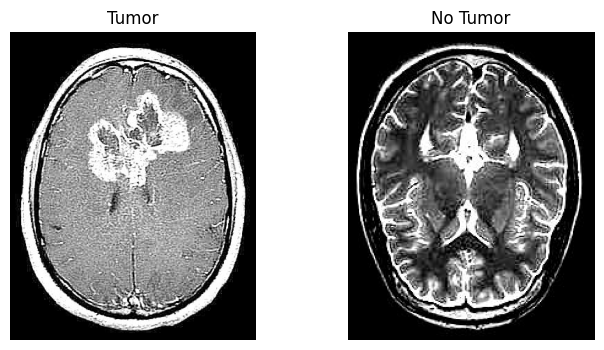

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
import os

# Select one image from each class
sample_yes = os.path.join(yes_path, yes_images[0])
sample_no = os.path.join(no_path, no_images[0])

img_yes = Image.open(sample_yes)
img_no = Image.open(sample_no)

print("Tumor image size:", img_yes.size)
print("No tumor image size:", img_no.size)

plt.figure(figsize=(8, 4))

plt.subplot(1, 2, 1)
plt.imshow(img_yes, cmap="gray")
plt.title("Tumor")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(img_no, cmap="gray")
plt.title("No Tumor")
plt.axis("off")

plt.show()

In [22]:
import shutil
import os
import kagglehub # Added this import statement

# Ensure the dataset is downloaded and get its path
# This replaces the hardcoded path with a call to download the dataset
path = kagglehub.dataset_download("ahmedhamada0/brain-tumor-detection")

# Define yes_path, no_path, yes_images, and no_images using the obtained path
yes_path = os.path.join(path, "yes")   # tumor images
no_path = os.path.join(path, "no")     # no tumor images

yes_images = os.listdir(yes_path)
no_images = os.listdir(no_path)

clean_dir = "/content/brain_tumor_binary"

# Remove old clean folder if it already exists
if os.path.exists(clean_dir):
    shutil.rmtree(clean_dir)

# Create clean class folders
os.makedirs(os.path.join(clean_dir, "tumor"))
os.makedirs(os.path.join(clean_dir, "no_tumor"))

# Copy images into clean folders
for img in yes_images:
    shutil.copy(os.path.join(yes_path, img), os.path.join(clean_dir, "tumor", img))

for img in no_images:
    shutil.copy(os.path.join(no_path, img), os.path.join(clean_dir, "no_tumor", img))

print("Clean dataset created successfully!")
print("Tumor images:", len(os.listdir(os.path.join(clean_dir, "tumor"))))
print("No tumor images:", len(os.listdir(os.path.join(clean_dir, "no_tumor"))))
print("Clean dataset path:", clean_dir)

Using Colab cache for faster access to the 'brain-tumor-detection' dataset.
Clean dataset created successfully!
Tumor images: 1500
No tumor images: 1500
Clean dataset path: /content/brain_tumor_binary


In [23]:
import os
import shutil
import random

# Clean binary dataset path from previous step
source_dir = "/content/brain_tumor_binary"

# New split dataset folder
split_dir = "/content/brain_tumor_split"

# Remove old split folder if exists
if os.path.exists(split_dir):
    shutil.rmtree(split_dir)

# Create train, validation, test folders
classes = ["tumor", "no_tumor"]
splits = ["train", "val", "test"]

for split in splits:
    for cls in classes:
        os.makedirs(os.path.join(split_dir, split, cls))

# Split ratio: 70% train, 15% validation, 15% test
train_ratio = 0.70
val_ratio = 0.15
test_ratio = 0.15

random.seed(42)

for cls in classes:
    class_path = os.path.join(source_dir, cls)

    # Diagnostic check: Ensure source directory exists and is not empty
    if not os.path.exists(class_path):
        print(f"Warning: Source directory '{class_path}' does not exist. Please ensure cell NGiZqpV4l8Fv was executed successfully.")
        continue # Skip this class if directory doesn't exist

    images = os.listdir(class_path)

    if not images:
        print(f"Warning: No images found in '{class_path}'. Please ensure cell NGiZqpV4l8Fv was executed successfully and populated this directory.")
        continue # Skip this class if no images are found

    random.shuffle(images)

    total = len(images)
    train_end = int(total * train_ratio)
    val_end = train_end + int(total * val_ratio)

    train_images = images[:train_end]
    val_images = images[train_end:val_end]
    test_images = images[val_end:]

    for img in train_images:
        shutil.copy(os.path.join(class_path, img), os.path.join(split_dir, "train", cls, img))

    for img in val_images:
        shutil.copy(os.path.join(class_path, img), os.path.join(split_dir, "val", cls, img))

    for img in test_images:
        shutil.copy(os.path.join(class_path, img), os.path.join(split_dir, "test", cls, img))

print("Dataset split completed successfully!")

for split in splits:
    print("\n", split.upper())
    for cls in classes:
        print(cls, ":", len(os.listdir(os.path.join(split_dir, split, cls))))

Dataset split completed successfully!

 TRAIN
tumor : 1050
no_tumor : 1050

 VAL
tumor : 225
no_tumor : 225

 TEST
tumor : 225
no_tumor : 225


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping
import os
import shutil # Added for dataset splitting logic
import random # Added for dataset splitting logic
import kagglehub # Added to ensure dataset download for self-sufficiency
from PIL import Image # Added for diagnostic check
import time # Import time for sleep

# Improve dataset loading performance
AUTOTUNE = tf.data.AUTOTUNE

# Define the path to the split dataset
split_dir = "/content/brain_tumor_split"
source_dir = "/content/brain_tumor_binary" # Path to the clean dataset

# Declare all_copied_train_images at the cell level for consistent access
all_copied_train_images = {}

# --- NEW LOGIC: Ensure source_dir is populated (from NGiZqpV4l8Fv) ---
tumor_source_path = os.path.join(source_dir, "tumor")
no_tumor_source_path = os.path.join(source_dir, "no_tumor")

# Check if source_dir and its subdirectories (tumor, no_tumor) exist and are populated
if not (os.path.exists(tumor_source_path) and os.path.exists(no_tumor_source_path) and \
        len(os.listdir(tumor_source_path)) > 0 and len(os.listdir(no_tumor_source_path)) > 0):
    print(f"Warning: Source directory '{source_dir}' not found or not fully populated. Re-creating clean dataset now...")

    # Logic from NGiZqpV4l8Fv to create clean_dir (source_dir)
    path = kagglehub.dataset_download("ahmedhamada0/brain-tumor-detection")
    yes_path = os.path.join(path, "yes")
    no_path = os.path.join(path, "no")

    yes_images = os.listdir(yes_path)
    no_images = os.listdir(no_path)

    # Remove old clean folder if it already exists
    if os.path.exists(source_dir):
        shutil.rmtree(source_dir)

    # Create clean class folders
    os.makedirs(tumor_source_path)
    os.makedirs(no_tumor_source_path)

    # Copy images into clean folders
    for img in yes_images:
        shutil.copy(os.path.join(yes_path, img), os.path.join(tumor_source_path, img))
    for img in no_images:
        shutil.copy(os.path.join(no_path, img), os.path.join(no_tumor_source_path, img))

    print("Clean dataset re-created successfully within the training cell!")
    print("Tumor images in source:", len(os.listdir(tumor_source_path)))
    print("No tumor images in source:", len(os.listdir(no_tumor_source_path)))
# --- END NEW LOGIC ---

# Diagnostic check: Ensure the training directory exists and is populated.
# For robustness against transient filesystem issues, always re-create the dataset splits within this cell.
train_path = os.path.join(split_dir, "train")

print(f"Re-creating dataset splits in '{split_dir}' now for robustness...")

# Remove old split folder if exists
if os.path.exists(split_dir):
    shutil.rmtree(split_dir)

# Create train, validation, test folders
classes = ["tumor", "no_tumor"]
splits = ["train", "val", "test"]

for split in splits:
    for cls in classes:
        os.makedirs(os.path.join(split_dir, split, cls))

# Split ratio: 70% train, 15% validation, 15% test
train_ratio = 0.70
val_ratio = 0.15
test_ratio = 0.15

random.seed(42)

for cls in classes:
    class_path = os.path.join(source_dir, cls)

    # This check is now robust due to the prior block ensuring source_dir exists
    if not os.path.exists(class_path):
        # This error should ideally not be reached if the above block worked.
        raise FileNotFoundError(f"Error: Source directory '{class_path}' not found after re-creation attempt.")

    images = os.listdir(class_path)

    if not images:
        # This error should ideally not be reached if the above block worked.
        raise ValueError(f"Error: No images found in '{class_path}' after re-creation attempt.")

    random.shuffle(images)

    total = len(images)
    train_end = int(total * train_ratio)
    val_end = train_end + int(total * val_ratio)

    train_images = images[:train_end]
    val_images = images[train_end:val_end]
    test_images = images[val_end:]

    all_copied_train_images[cls] = []

    for img in train_images:
        dest_path = os.path.join(split_dir, "train", cls, img)
        shutil.copy(os.path.join(class_path, img), dest_path)
        all_copied_train_images[cls].append(dest_path) # Store full path

    for img in val_images:
        shutil.copy(os.path.join(class_path, img), os.path.join(split_dir, "val", cls, img))

    for img in test_images:
        shutil.copy(os.path.join(class_path, img), os.path.join(split_dir, "test", cls, img))

print("--- DEBUG: Waiting 1 second after copying to ensure filesystem sync ---")
time.sleep(1) # Wait a bit to ensure filesystem is consistent

print("Dataset split re-created successfully within the training cell!")
print("\n TRAIN\ntumor :", len(os.listdir(os.path.join(split_dir, 'train', 'tumor'))))
print("no_tumor :", len(os.listdir(os.path.join(split_dir, 'train', 'no_tumor'))))
print("\n VAL\ntumor :", len(os.listdir(os.path.join(split_dir, 'val', 'tumor'))))
print("no_tumor :", len(os.listdir(os.path.join(split_dir, 'val', 'no_tumor'))))
print("\n TEST\ntumor :", len(os.listdir(os.path.join(split_dir, 'test', 'tumor'))))
print("no_tumor :", len(os.listdir(os.path.join(split_dir, 'test', 'no_tumor'))))

# Detailed verification of a specific copied file immediately after creation and counts
print("\n--- DEBUG: Verifying a specific copied file immediately after counts ---")
if 'tumor' in all_copied_train_images and all_copied_train_images['tumor']:
    sample_tumor_file = all_copied_train_images['tumor'][0]
    if os.path.exists(sample_tumor_file):
        print(f"DEBUG: Confirmed existence of {sample_tumor_file}. Size: {os.path.getsize(sample_tumor_file)} bytes.")
        try:
            Image.open(sample_tumor_file).verify()
            print("DEBUG: PIL verified sample tumor image.")
        except Exception as e:
            print(f"DEBUG: PIL verification failed for {sample_tumor_file}: {e}")
    else:
        print(f"DEBUG: CRITICAL: {sample_tumor_file} does NOT exist immediately after copying and counts.")
else:
    print("DEBUG: No tumor images were recorded as copied to the train set.")

# Add diagnostic checks for copied files before image_dataset_from_directory
print("\n--- Diagnostic Check: Copied File Integrity (Post-if-block) ---")

# Check the same sample tumor image from the train set again
sample_tumor_train_path_for_final_check = None
if 'tumor' in all_copied_train_images and all_copied_train_images['tumor']:
    sample_tumor_train_path_for_final_check = all_copied_train_images['tumor'][0]

if sample_tumor_train_path_for_final_check:
    print(f"DEBUG: Final check on specific copied file: '{sample_tumor_train_path_for_final_check}'")
    if os.path.exists(sample_tumor_train_path_for_final_check):
        file_size_tumor = os.path.getsize(sample_tumor_train_path_for_final_check)
        print(f"DEBUG: Sample train tumor image '{os.path.basename(sample_tumor_train_path_for_final_check)}' size: {file_size_tumor} bytes")
        if file_size_tumor == 0:
            print("CRITICAL ERROR: Sample tumor image is zero-length!")
        else:
            try:
                Image.open(sample_tumor_train_path_for_final_check).verify() # Verify file is a valid image
                print("PIL successfully verified sample tumor image.")
            except Exception as e:
                print(f"PIL verification failed for sample tumor image: {e}")
    else:
        print(f"CRITICAL ERROR: Sample train tumor image does not exist at {sample_tumor_train_path_for_final_check} (post-if block).")
else:
    print(f"DEBUG: No sample tumor image path available for final check.")

current_tumor_train_path_list = os.listdir(os.path.join(split_dir, 'train', 'tumor'))
print(f"DEBUG: os.listdir('{os.path.join(split_dir, 'train', 'tumor')}') returned {len(current_tumor_train_path_list)} items.")
if not current_tumor_train_path_list:
    print(f"No tumor images found in {os.path.join(split_dir, 'train', 'tumor')}")

current_no_tumor_train_path_list = os.listdir(os.path.join(split_dir, 'train', 'no_tumor'))
print(f"DEBUG: os.listdir('{os.path.join(split_dir, 'train', 'no_tumor')}') returned {len(current_no_tumor_train_path_list)} items.")
if not current_no_tumor_train_path_list:
    print(f"No no_tumor images found in {os.path.join(split_dir, 'train', 'no_tumor')}")

print("--- End Diagnostic Check ---")

# Load image datasets
train_data = tf.keras.utils.image_dataset_from_directory(
    train_path,
    labels="inferred",
    label_mode="binary",
    image_size=(224, 224),
    interpolation="nearest",
    batch_size=32,
    shuffle=True
)

val_data = tf.keras.utils.image_dataset_from_directory(
    os.path.join(split_dir, "val"),
    labels="inferred",
    label_mode="binary",
    image_size=(224, 224),
    interpolation="nearest",
    batch_size=32,
    shuffle=False
)

test_data = tf.keras.utils.image_dataset_from_directory(
    os.path.join(split_dir, "test"),
    labels="inferred",
    label_mode="binary",
    image_size=(224, 224),
    interpolation="nearest",
    batch_size=32,
    shuffle=False
)

train_data = train_data.prefetch(buffer_size=AUTOTUNE)
val_data = val_data.prefetch(buffer_size=AUTOTUNE)
test_data = test_data.prefetch(buffer_size=AUTOTUNE)

# Data augmentation to reduce overfitting
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1)
])

# Build custom CNN model
cnn_model = models.Sequential([
    layers.Input(shape=(224, 224, 3)),

    # Normalize pixel values from 0-255 to 0-1
    layers.Rescaling(1./255),

    # Apply data augmentation
    data_augmentation,

    # Convolution block 1
    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    # Convolution block 2
    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    # Convolution block 3
    layers.Conv2D(128, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    # Fully connected classification layers
    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(1, activation="sigmoid")
])

# Compile the CNN model
cnn_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# Display model architecture
cnn_model.summary()

# Early stopping to reduce overfitting
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

# Train the custom CNN model
history_cnn = cnn_model.fit(
    train_data,
    validation_data=val_data,
    epochs=15,
    callbacks=[early_stop]
)

Re-creating dataset splits in '/content/brain_tumor_split' now for robustness...
--- DEBUG: Waiting 1 second after copying to ensure filesystem sync ---
Dataset split re-created successfully within the training cell!

 TRAIN
tumor : 1050
no_tumor : 1050

 VAL
tumor : 225
no_tumor : 225

 TEST
tumor : 225
no_tumor : 225

--- DEBUG: Verifying a specific copied file immediately after counts ---
DEBUG: Confirmed existence of /content/brain_tumor_split/train/tumor/y171.jpg. Size: 16536 bytes.
DEBUG: PIL verified sample tumor image.

--- Diagnostic Check: Copied File Integrity (Post-if-block) ---
DEBUG: Final check on specific copied file: '/content/brain_tumor_split/train/tumor/y171.jpg'
DEBUG: Sample train tumor image 'y171.jpg' size: 16536 bytes
PIL successfully verified sample tumor image.
DEBUG: os.listdir('/content/brain_tumor_split/train/tumor') returned 1050 items.
DEBUG: os.listdir('/content/brain_tumor_split/train/no_tumor') returned 1050 items.
--- End Diagnostic Check ---
Found 2

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,089 (42.61 MB)

 Trainable params: 11,169,089 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 306s 5s/step - accuracy: 0.7229 - loss: 0.6367 - val_accuracy: 0.8244 - val_loss: 0.4927
Epoch 2/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 294s 4s/step - accuracy: 0.7729 - loss: 0.4949 - val_accuracy: 0.8244 - val_loss: 0.3923
Epoch 3/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 281s 4s/step - accuracy: 0.7786 - loss: 0.4801 - val_accuracy: 0.8289 - val_loss: 0.3866
Epoch 4/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 273s 4s/step - accuracy: 0.8095 - loss: 0.4279 - val_accuracy: 0.8556 - val_loss: 0.3453
Epoch 5/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 328s 4s/step - accuracy: 0.8229 - loss: 0.4125 - val_accuracy: 0.8711 - val_loss: 0.3150
Epoch 6/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 274s 4s/step - accuracy: 0.8381 - loss: 0.3878 - val_accuracy: 0.8289 - val_loss: 0.3713
Epoch 7/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 278s 4s/step - accuracy: 0.8457 - loss: 0.3488 - val_accuracy: 0.8644 - val_loss: 0.3027
Epoch 8/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 274s 4s/step - accuracy: 0.8524 - loss: 0.3571 - val_accuracy: 0.8844 - v

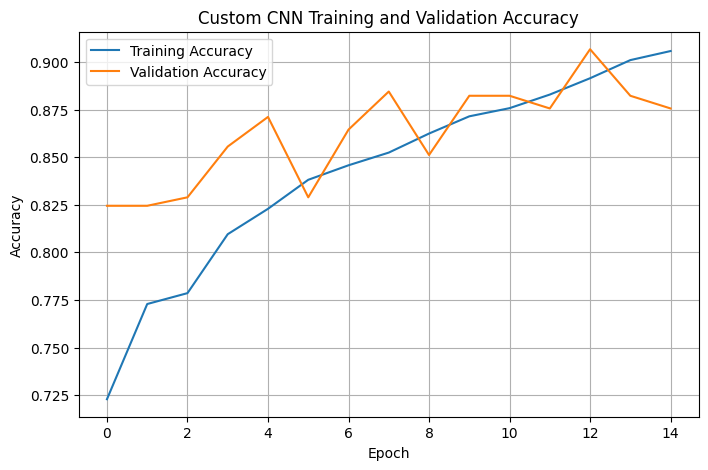

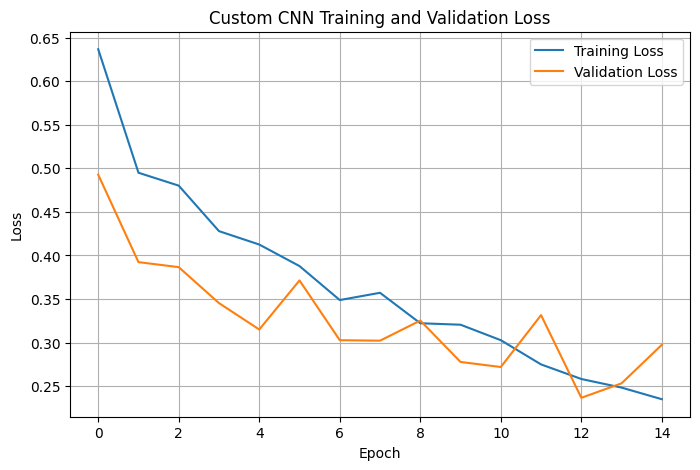

In [19]:
import matplotlib.pyplot as plt

# Accuracy graph
plt.figure(figsize=(8, 5))
plt.plot(history_cnn.history['accuracy'], label='Training Accuracy')
plt.plot(history_cnn.history['val_accuracy'], label='Validation Accuracy')
plt.title('Custom CNN Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# Loss graph
plt.figure(figsize=(8, 5))
plt.plot(history_cnn.history['loss'], label='Training Loss')
plt.plot(history_cnn.history['val_loss'], label='Validation Loss')
plt.title('Custom CNN Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

15/15 ━━━━━━━━━━━━━━━━━━━━ 20s 1s/step - accuracy: 0.8711 - loss: 0.3142
Custom CNN Test Accuracy: 0.8711110949516296
Custom CNN Test Loss: 0.3141910433769226
15/15 ━━━━━━━━━━━━━━━━━━━━ 19s 1s/step
Classification Report for Custom CNN:
              precision    recall  f1-score   support

    No Tumor       0.93      0.80      0.86       225
       Tumor       0.82      0.94      0.88       225

    accuracy                           0.87       450
   macro avg       0.88      0.87      0.87       450
weighted avg       0.88      0.87      0.87       450



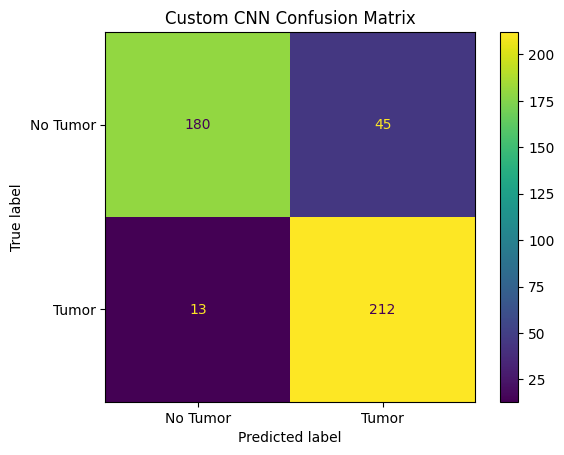

Custom CNN Metrics
Accuracy: 0.8711111111111111
Precision: 0.8249027237354085
Recall: 0.9422222222222222
F1-score: 0.8796680497925311


In [20]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# Evaluate model on test data
test_loss, test_accuracy = cnn_model.evaluate(test_data)

print("Custom CNN Test Accuracy:", test_accuracy)
print("Custom CNN Test Loss:", test_loss)

# Get true labels
y_true = np.concatenate([y.numpy() for x, y in test_data], axis=0).astype(int).reshape(-1)

# Get predicted probabilities
y_pred_prob = cnn_model.predict(test_data)

# Convert probabilities to class labels
y_pred = (y_pred_prob > 0.5).astype(int).reshape(-1)

# Classification report
print("Classification Report for Custom CNN:")
print(classification_report(y_true, y_pred, target_names=["No Tumor", "Tumor"]))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Tumor", "Tumor"]
)

disp.plot()
plt.title("Custom CNN Confusion Matrix")
plt.show()

# Store metrics for later comparison
cnn_accuracy = accuracy_score(y_true, y_pred)
cnn_precision = precision_score(y_true, y_pred)
cnn_recall = recall_score(y_true, y_pred)
cnn_f1 = f1_score(y_true, y_pred)

print("Custom CNN Metrics")
print("Accuracy:", cnn_accuracy)
print("Precision:", cnn_precision)
print("Recall:", cnn_recall)
print("F1-score:", cnn_f1)

In [21]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

# Load pre-trained MobileNetV2 model without top classification layer
base_model = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)

# Freeze base model layers
base_model.trainable = False

# Build transfer learning model
mobilenet_model = models.Sequential([
    layers.Input(shape=(224, 224, 3)),

    # Preprocessing required for MobileNetV2
    layers.Lambda(preprocess_input),

    # Pre-trained base model
    base_model,

    # Classification head
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.4),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(1, activation="sigmoid")
])

# Compile model
mobilenet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# Show model summary
mobilenet_model.summary()

# Early stopping
early_stop_mobile = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

# Train MobileNetV2 model
history_mobile = mobilenet_model.fit(
    train_data,
    validation_data=val_data,
    epochs=10,
    callbacks=[early_stop_mobile]
)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lambda (Lambda)                 │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Epoch 1/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 120s 2s/step - accuracy: 0.6271 - loss: 0.6981 - val_accuracy: 0.8133 - val_loss: 0.4482
Epoch 2/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 110s 2s/step - accuracy: 0.7586 - loss: 0.4981 - val_accuracy: 0.8800 - val_loss: 0.3500
Epoch 3/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 141s 2s/step - accuracy: 0.8086 - loss: 0.4264 - val_accuracy: 0.8933 - val_loss: 0.2980
Epoch 4/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 111s 2s/step - accuracy: 0.8386 - loss: 0.3709 - val_accuracy: 0.9156 - val_loss: 0.2549
Epoch 5/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 111s 2s/step - accuracy: 0.8586 - loss: 0.3359 - val_accuracy: 0.9156 - val_loss: 0.2327
Epoch 6/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 111s 2s/step - accuracy: 0.8748 - loss: 0.3079 - val_accuracy: 0.9222 - val_loss: 0.2110
Epoch 7/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 140s 2s/step - accuracy: 0.8790 - loss: 0.2884 - val_accuracy: 0.9333 - val_loss: 0.1994
Epoch 8/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 111s 2s/step - accuracy: 0.8900 - loss: 0.2788 - val_accuracy: 0.9289 - v

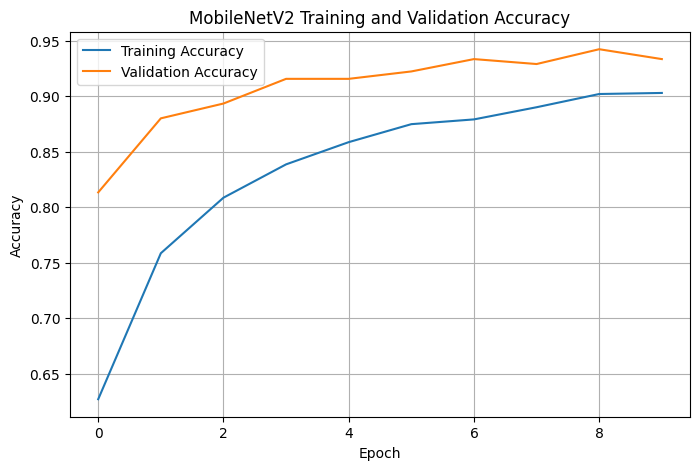

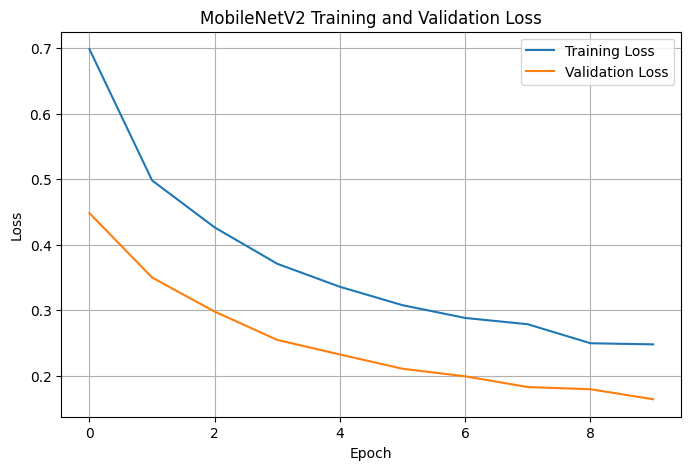

In [22]:
import matplotlib.pyplot as plt

# Accuracy graph
plt.figure(figsize=(8, 5))
plt.plot(history_mobile.history['accuracy'], label='Training Accuracy')
plt.plot(history_mobile.history['val_accuracy'], label='Validation Accuracy')
plt.title('MobileNetV2 Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# Loss graph
plt.figure(figsize=(8, 5))
plt.plot(history_mobile.history['loss'], label='Training Loss')
plt.plot(history_mobile.history['val_loss'], label='Validation Loss')
plt.title('MobileNetV2 Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

15/15 ━━━━━━━━━━━━━━━━━━━━ 19s 1s/step - accuracy: 0.9378 - loss: 0.1988
MobileNetV2 Test Accuracy: 0.9377777576446533
MobileNetV2 Test Loss: 0.19877420365810394
15/15 ━━━━━━━━━━━━━━━━━━━━ 23s 1s/step
Classification Report for MobileNetV2:
              precision    recall  f1-score   support

    No Tumor       0.93      0.95      0.94       225
       Tumor       0.95      0.93      0.94       225

    accuracy                           0.94       450
   macro avg       0.94      0.94      0.94       450
weighted avg       0.94      0.94      0.94       450



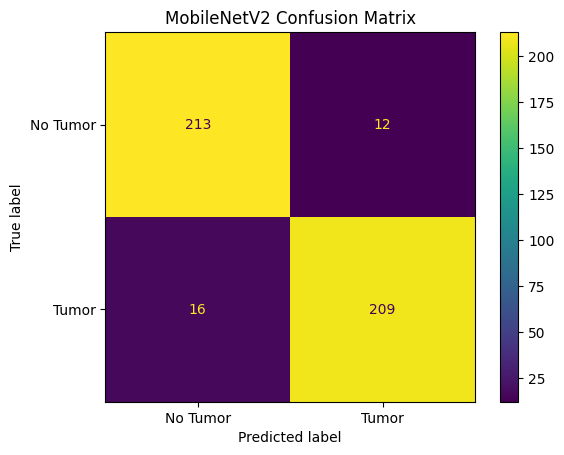

MobileNetV2 Metrics
Accuracy: 0.9377777777777778
Precision: 0.9457013574660633
Recall: 0.9288888888888889
F1-score: 0.9372197309417041


In [23]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Evaluate model on test data
mobile_test_loss, mobile_test_accuracy = mobilenet_model.evaluate(test_data)

print("MobileNetV2 Test Accuracy:", mobile_test_accuracy)
print("MobileNetV2 Test Loss:", mobile_test_loss)

# True labels
y_true_mobile = np.concatenate([y.numpy() for x, y in test_data], axis=0).astype(int).reshape(-1)

# Predicted probabilities
y_pred_prob_mobile = mobilenet_model.predict(test_data)

# Convert probabilities into class labels
y_pred_mobile = (y_pred_prob_mobile > 0.5).astype(int).reshape(-1)

# Classification report
print("Classification Report for MobileNetV2:")
print(classification_report(y_true_mobile, y_pred_mobile, target_names=["No Tumor", "Tumor"]))

# Confusion matrix
cm_mobile = confusion_matrix(y_true_mobile, y_pred_mobile)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_mobile,
    display_labels=["No Tumor", "Tumor"]
)

disp.plot()
plt.title("MobileNetV2 Confusion Matrix")
plt.show()

# Store metrics for comparison table
mobile_accuracy = accuracy_score(y_true_mobile, y_pred_mobile)
mobile_precision = precision_score(y_true_mobile, y_pred_mobile)
mobile_recall = recall_score(y_true_mobile, y_pred_mobile)
mobile_f1 = f1_score(y_true_mobile, y_pred_mobile)

print("MobileNetV2 Metrics")
print("Accuracy:", mobile_accuracy)
print("Precision:", mobile_precision)
print("Recall:", mobile_recall)
print("F1-score:", mobile_f1)

In [24]:
import pandas as pd

# Create comparison table
comparison_table = pd.DataFrame({
    "Model": ["Custom CNN", "MobileNetV2"],
    "Accuracy": [cnn_accuracy, mobile_accuracy],
    "Precision": [cnn_precision, mobile_precision],
    "Recall": [cnn_recall, mobile_recall],
    "F1-score": [cnn_f1, mobile_f1]
})

# Round values for clean presentation
comparison_table = comparison_table.round(4)

print("Final Comparison Table:")
display(comparison_table)

Final Comparison Table:


,Model,Accuracy,Precision,Recall,F1-score
0,Custom CNN,0.8711,0.8249,0.9422,0.8797
1,MobileNetV2,0.9378,0.9457,0.9289,0.9372


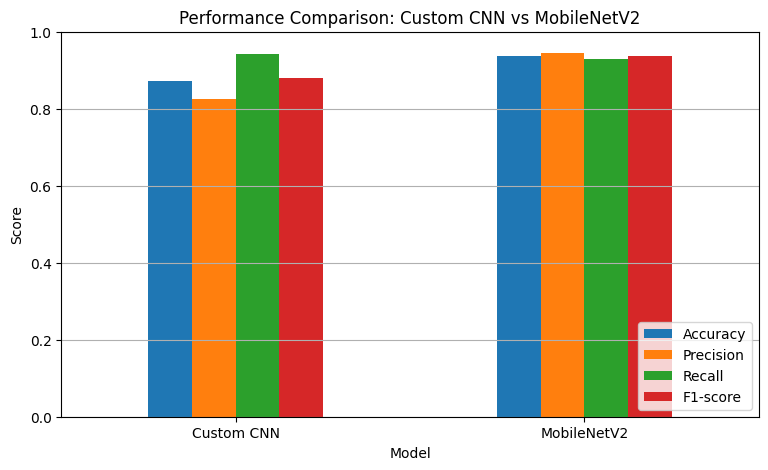

In [25]:
import matplotlib.pyplot as plt

comparison_table.set_index("Model").plot(kind="bar", figsize=(9, 5))

plt.title("Performance Comparison: Custom CNN vs MobileNetV2")
plt.ylabel("Score")
plt.xlabel("Model")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.grid(axis="y")
plt.show()

In [26]:
# Save Custom CNN model
cnn_model.save("/content/custom_cnn_brain_tumor_model.h5")

# Save MobileNetV2 model
mobilenet_model.save("/content/mobilenetv2_brain_tumor_model.h5")

print("Both models saved successfully!")

Both models saved successfully!


In [27]:
from google.colab import files

files.download("/content/custom_cnn_brain_tumor_model.h5")
files.download("/content/mobilenetv2_brain_tumor_model.h5")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>